In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('food_waste_dataset.csv')

In [3]:
df.head()
print("Shape of dataset:", df.shape)

df.info()
df.describe()

df.dtypes

Shape of dataset: (8000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Inventory_ID         8000 non-null   object 
 1   Date                 8000 non-null   object 
 2   Business_Type        8000 non-null   object 
 3   Food_Category        8000 non-null   object 
 4   Purchase_Quantity    8000 non-null   int64  
 5   Units_Sold           8000 non-null   int64  
 6   Remaining_Stock      8000 non-null   int64  
 7   Shelf_Life_Days      7765 non-null   float64
 8   Storage_Temperature  7814 non-null   float64
 9   Daily_Demand         7790 non-null   float64
 10  Promotion            8000 non-null   object 
 11  Weather              7797 non-null   object 
 12  Waste_Quantity       8000 non-null   int64  
 13  Waste_Reason         8000 non-null   object 
 14  Donation_Made        7767 non-null   object 
 15  Waste_Lev

,0
Inventory_ID,object
Date,object
Business_Type,object
Food_Category,object
Purchase_Quantity,int64
Units_Sold,int64
Remaining_Stock,int64
Shelf_Life_Days,float64
Storage_Temperature,float64
Daily_Demand,float64


In [4]:
df.isnull().sum()

,0
Inventory_ID,0
Date,0
Business_Type,0
Food_Category,0
Purchase_Quantity,0
Units_Sold,0
Remaining_Stock,0
Shelf_Life_Days,235
Storage_Temperature,186
Daily_Demand,210


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()

In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_366/485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [8]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_366/2213161713.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
df.isnull().sum()

,0
Inventory_ID,0
Date,0
Business_Type,0
Food_Category,0
Purchase_Quantity,0
Units_Sold,0
Remaining_Stock,0
Shelf_Life_Days,0
Storage_Temperature,0
Daily_Demand,0


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print(df.isnull().sum())

Duplicate rows: 0
Inventory_ID           0
Date                   0
Business_Type          0
Food_Category          0
Purchase_Quantity      0
Units_Sold             0
Remaining_Stock        0
Shelf_Life_Days        0
Storage_Temperature    0
Daily_Demand           0
Promotion              0
Weather                0
Waste_Quantity         0
Waste_Reason           0
Donation_Made          0
Waste_Level            0
dtype: int64


In [17]:
df = df.drop_duplicates()

In [18]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

Major data quality issues:

Missing values in some columns.
Duplicate records.
Incorrect data types (especially Date column).
Possible outliers in quantity and waste-related fields.

Impact: These issues can lead to inaccurate results, biased analysis, and reduced machine learning model performance. Proper cleaning improves the reliability of predictions and insights.

Waste level vs Business

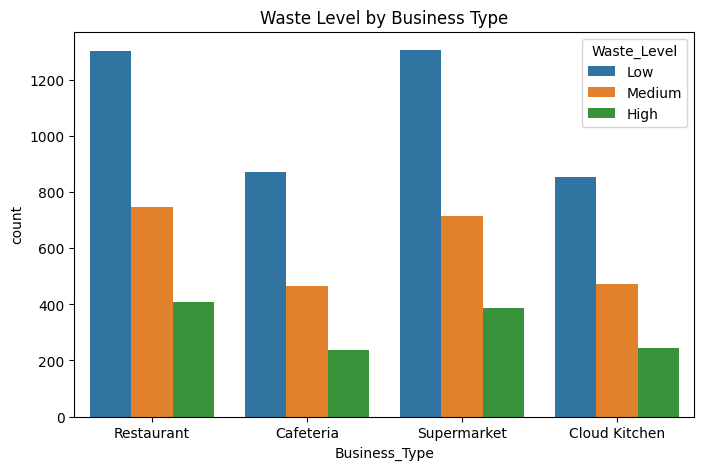

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='Business_Type', hue='Waste_Level', data=df)
plt.title('Waste Level by Business Type')
plt.show()

Waste Level vs Food Category

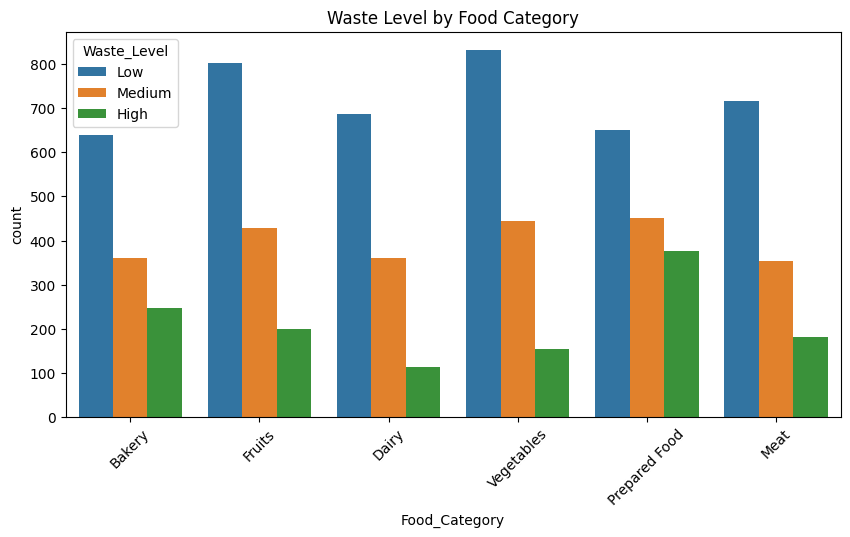

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x='Food_Category', hue='Waste_Level', data=df)
plt.xticks(rotation=45)
plt.title('Waste Level by Food Category')
plt.show()

Waste Level vs Purchase Quantity

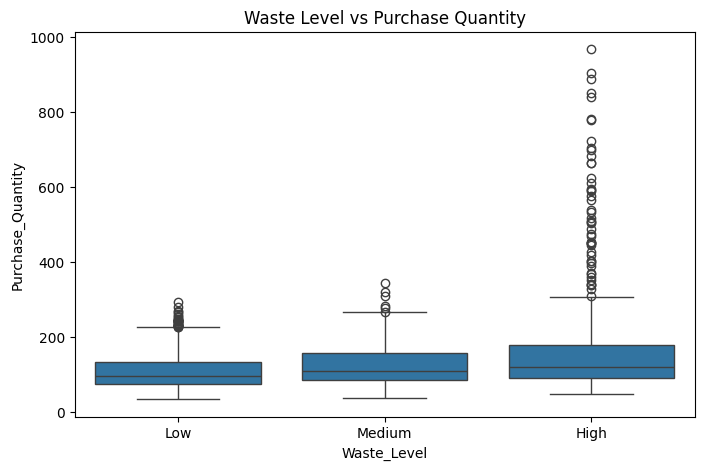

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Waste_Level', y='Purchase_Quantity', data=df)
plt.title('Waste Level vs Purchase Quantity')
plt.show()

Waste Level vs Units Sold

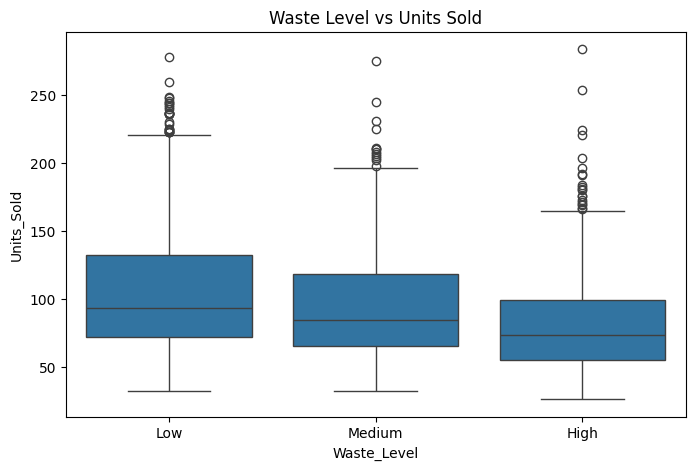

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Waste_Level', y='Units_Sold', data=df)
plt.title('Waste Level vs Units Sold')
plt.show()

Waste Level vs Weather

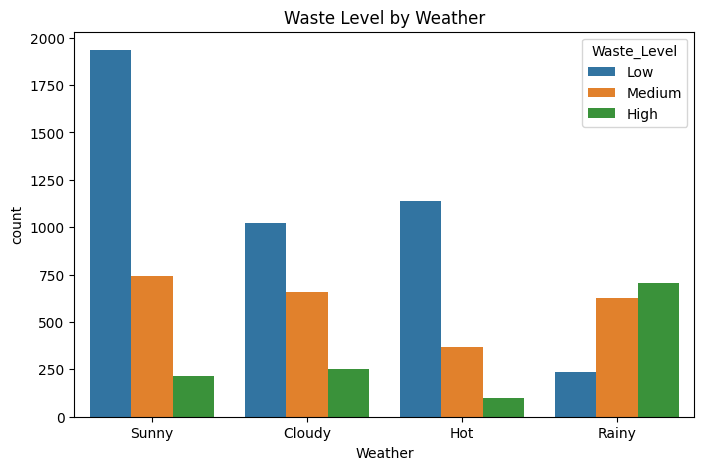

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Weather', hue='Waste_Level', data=df)
plt.title('Waste Level by Weather')
plt.show()

Waste Level vs Promotion

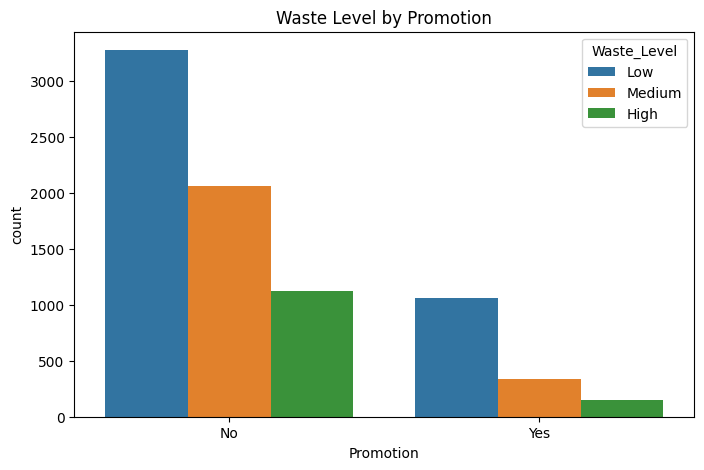

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='Promotion', hue='Waste_Level', data=df)
plt.title('Waste Level by Promotion')
plt.show()

Waste Level vs Waste Reason

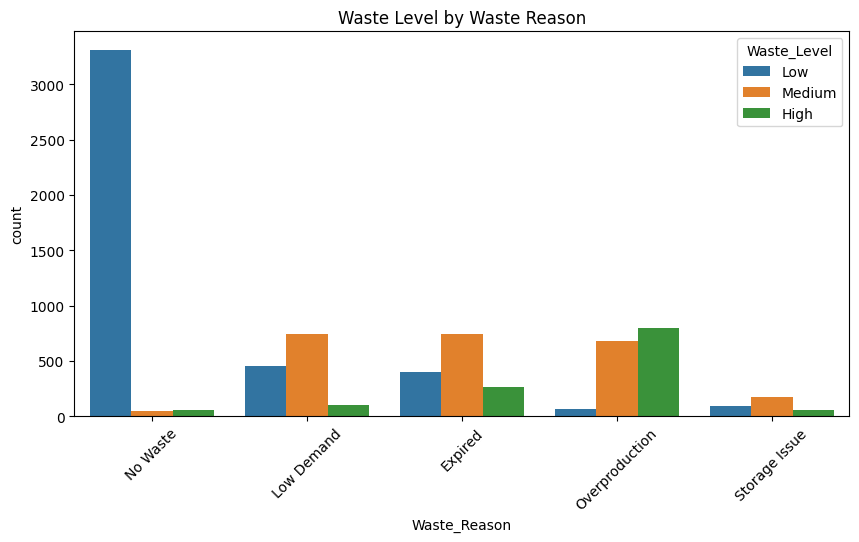

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='Waste_Reason', hue='Waste_Level', data=df)
plt.xticks(rotation=45)
plt.title('Waste Level by Waste Reason')
plt.show()

Waste Level vs Shelf Life

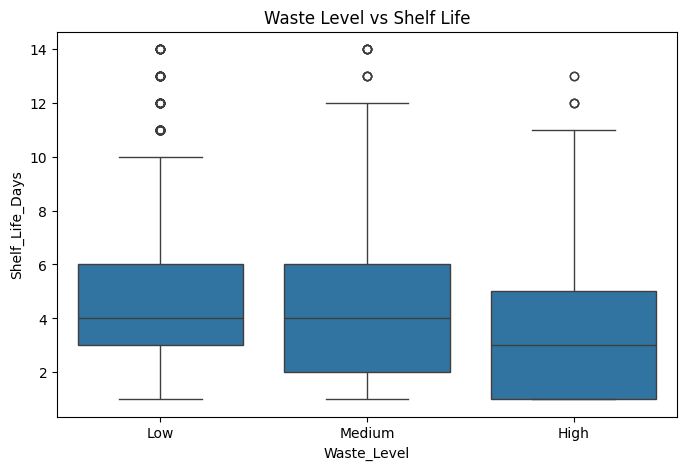

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Waste_Level', y='Shelf_Life_Days', data=df)
plt.title('Waste Level vs Shelf Life')
plt.show()

Waste Level vs Storage Temparature

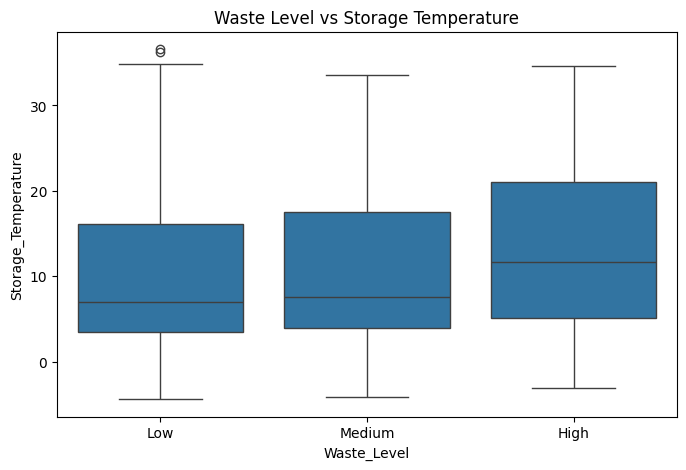

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Waste_Level', y='Storage_Temperature', data=df)
plt.title('Waste Level vs Storage Temperature')
plt.show()

Correlation Heatmap (Numerical Variables)

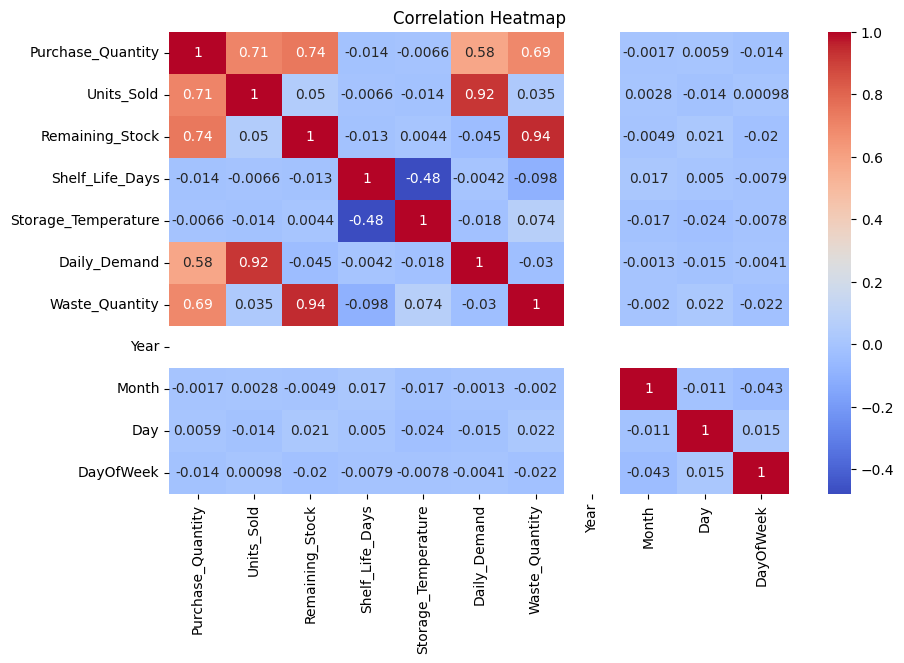

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Business type with highest waste

In [31]:
df.groupby('Business_Type')['Waste_Quantity'].sum().sort_values(ascending=False)

,Waste_Quantity
Business_Type,
Supermarket,21248
Restaurant,11144
Cloud Kitchen,8662
Cafeteria,5125


Food category with highest waste

In [32]:
df.groupby('Food_Category')['Waste_Quantity'].sum().sort_values(ascending=False)

,Waste_Quantity
Food_Category,
Prepared Food,13362
Fruits,7123
Bakery,7055
Vegetables,6684
Meat,6654
Dairy,5301


In [33]:
df['Waste_Reason'].value_counts()

,count
Waste_Reason,
No Waste,3415
Overproduction,1550
Expired,1411
Low Demand,1295
Storage Issue,329


The business type with the highest total waste is super market. The food category generating the highest waste is prepared food. The major reasons for food waste are overproduction, expiration,Low Demand and storage issues. These factors contribute significantly to increased waste levels and inventory losses.

Waste Reason showed the strongest relationship with Waste Quantity, followed by Purchase Quantity and Units Sold. Key patterns indicate that overproduction, low sales, short shelf life, and unfavorable demand conditions contribute significantly to food waste, while promotions can help reduce waste.

% of purchased food waste

In [34]:
df['Waste_Percentage'] = (df['Waste_Quantity'] / df['Purchase_Quantity']) * 100

SALES EFFICIENCY

In [35]:
df['Sales_Efficiency'] = (df['Units_Sold'] / df['Purchase_Quantity']) * 100

UNSOLD STOCK

In [36]:
df['Unsold_Stock'] = df['Purchase_Quantity'] - df['Units_Sold']

demand gap

In [37]:
df['Demand_Gap'] = df['Daily_Demand'] - df['Units_Sold']

In [38]:
features = ['Business_Type','Food_Category','Purchase_Quantity',
            'Units_Sold','Remaining_Stock','Shelf_Life_Days',
            'Daily_Demand','Waste_Quantity','Waste_Reason',
            'Promotion','Weather','Storage_Temperature',
            'Waste_Percentage','Sales_Efficiency',
            'Unsold_Stock','Demand_Gap']

X = df[features]
y = df['Waste_Level']

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

/tmp/ipykernel_366/3926775942.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_366/3926775942.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_366/3926775942.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



The most useful new features are Waste Percentage, Sales Efficiency, and Unsold Stock because they directly measure food waste and inventory performance.

The most useful existing features are Purchase Quantity, Units Sold, Shelf Life Days, and Waste Reason because they strongly influence how much food is wasted and explain the causes of waste.

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [44]:
if 'Date' in df.columns:
    df = df.drop('Date', axis=1)

In [46]:
X = df.drop('Waste_Level', axis=1)
y = df['Waste_Level']


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
import sklearn
print(sklearn.__version__)

1.6.1


In [52]:
!pip install scikit-learn

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [55]:
from sklearn.neighbors import KNeighborsClassifier


In [56]:
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [62]:
pred = rf.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.973125

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       229
           1       0.98      0.99      0.98       889
           2       0.96      0.97      0.97       482

    accuracy                           0.97      1600
   macro avg       0.97      0.96      0.96      1600
weighted avg       0.97      0.97      0.97      1600



In [65]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[211   8  10]
 [  3 877   9]
 [  4   9 469]]


1. Best Model

Random Forest performed best because it achieved the highest accuracy and handled complex data effectively.

2. Most Important Features

Waste Percentage, Waste Quantity, Purchase Quantity, Units Sold, and Shelf Life Days were the most important features.

3. Most Difficult Waste Category

Medium Waste Level was the hardest to predict due to overlap with Low and High waste levels.

4. Model Reliability

Yes, the model is reasonably reliable for business decisions as it achieved good accuracy and identified key waste factors. However, it should be used along with business judgment.

TASK 5

Major Factors Contributing to Food Waste
Excess purchasing and overproduction.
Low sales compared to inventory levels.
Short shelf-life products.
Product expiration and storage issues.
Demand fluctuations due to weather and promotions.

Strategies for Reducing Food Waste
Improve demand forecasting and inventory planning.
Reduce overstocking and unnecessary purchases.
Use targeted promotions to clear excess stock.
Monitor storage conditions regularly.
Prioritize the sale of near-expiry products.

Business Conditions Where High Waste Is More Likely
High inventory with low customer demand.
Products with short shelf life.
Ineffective inventory management.
Poor storage conditions.
Overproduction during slow sales periods.

If I were managing the business, I would prioritize:

Improve inventory planning and demand forecasting

Analysis showed that high purchase quantities and low sales are strongly associated with higher waste.

Reduce overproduction and excess stock

Overproduction was identified as a major reason for food waste, leading to unsold inventory.

Improve management of perishable products

Items with shorter shelf life and expired products contributed significantly to waste.

In [73]:
rf

RandomForestClassifier(random_state=42)

In [74]:
type(rf)

sklearn.ensemble._forest.RandomForestClassifier

In [75]:
from google.colab import files

files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 6 Analytical question

The Flask-based prediction system can be integrated into daily operations by allowing staff to enter inventory details such as purchase quantity, units sold, shelf life, and storage conditions before stocking or ordering products.

Inventory Planning

Predict high-waste items in advance and reduce excess purchasing.

Demand Forecasting

Adjust production and purchasing based on predicted waste levels to avoid overproduction.

Waste Monitoring

Identify products at high risk of spoilage and prioritize promotions or discounts to clear stock.

Evidence from Analysis:

In [76]:
import pickle

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [77]:
from google.colab import files
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [79]:
import pickle

with open('encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

In [80]:
from google.colab import files
files.download('encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>